Prediciendo la diabetes

In [263]:
import json
import pandas as pd

url = "https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv"

total_data = pd.read_csv(url)
total_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Step 2: Exploración y Limpieza de Datos

In [264]:
# Obtener las dimensiones
total_data.shape

(768, 9)

In [265]:
# Obtener información de las columnas con valores nulos
total_data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

El dataset está completo, sin huecos que rellenar.

Step 3: Análisis de variables univariantes

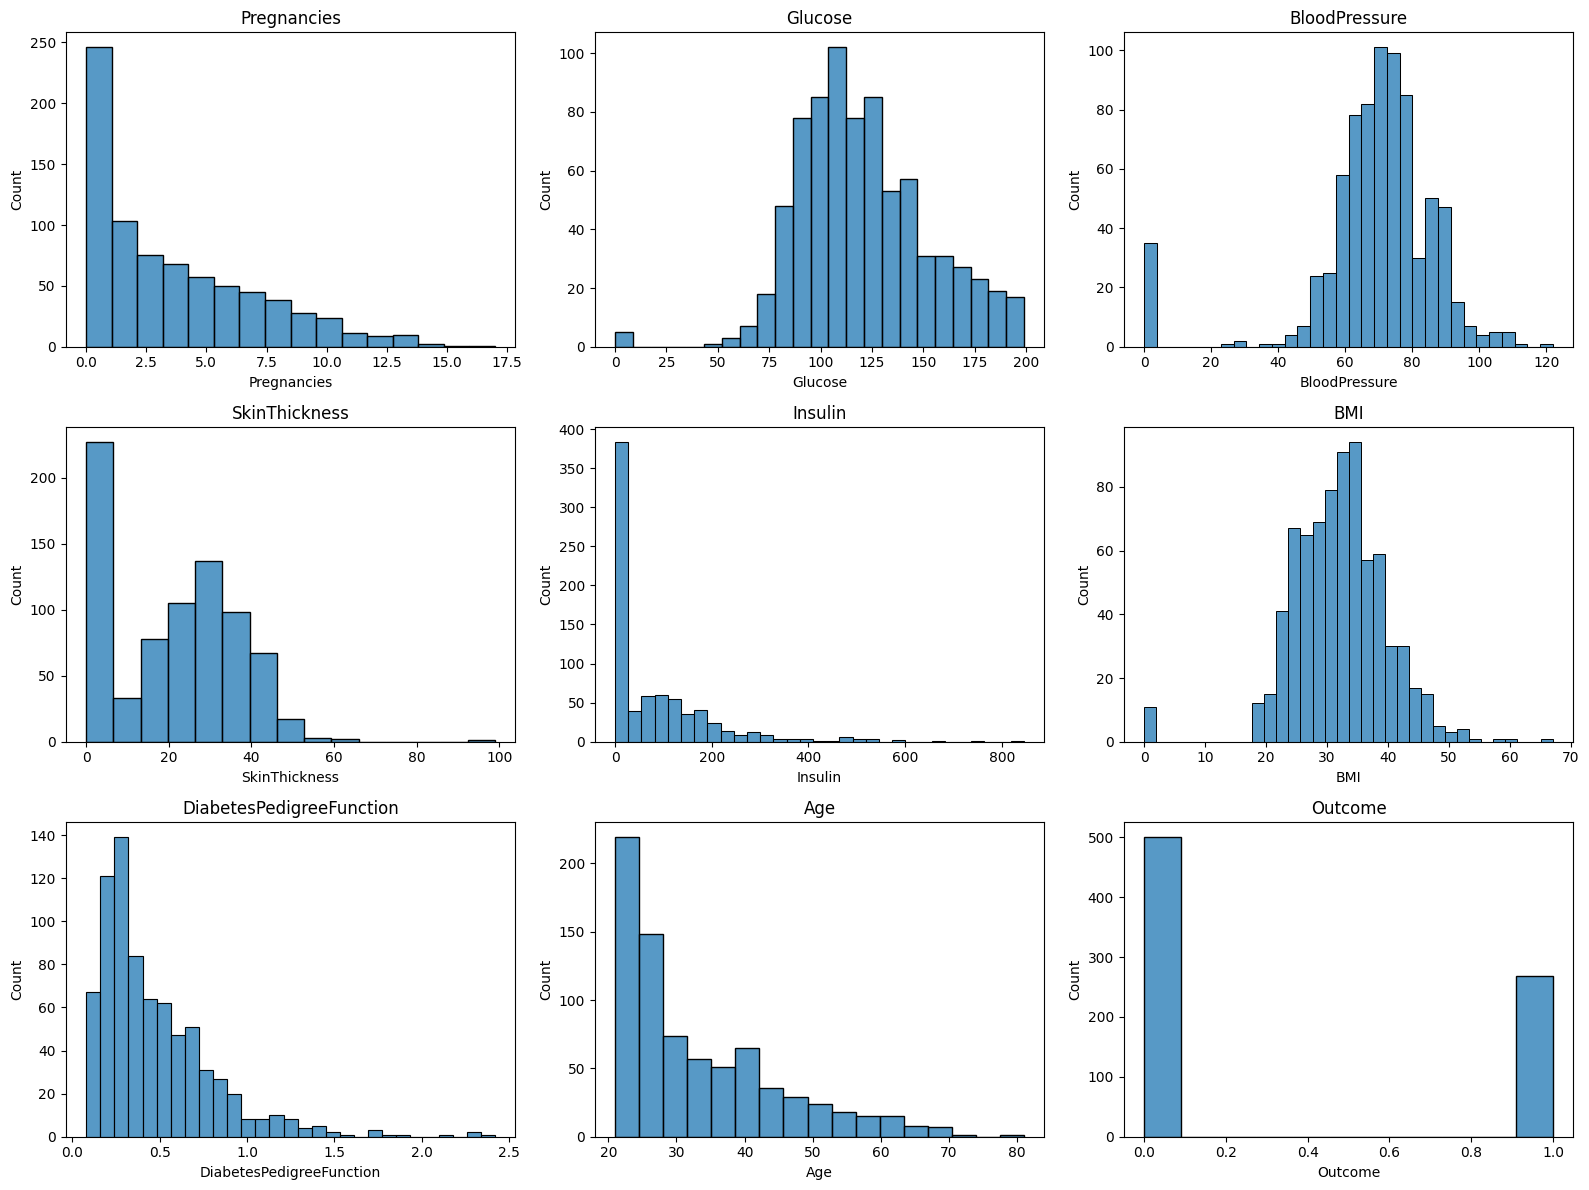

In [266]:
import seaborn as sns
import matplotlib.pyplot as plt

variables = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
             "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

fig, axis = plt.subplots(3, 3, figsize=(16, 12))

for i, var in enumerate(variables):
    fila = i // 3
    col = i % 3
    sns.histplot(ax=axis[fila, col], data=total_data, x=var)
    axis[fila, col].set_title(var)

plt.tight_layout()
plt.show()


Existen valores nulos en variables como 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin' y 'BMI' por lo que supone existencia de datos faltantes.
>Por su naturaleza de las variables:
Númericas continuas: 'BMI', 'Glucose', 'BloodPressure'
Numéricas discretas: 'Pregnancies'
Categóricas binarias: 'Outcome' (YES/NO)
En este caso, la variable objetivo es 'Outcome'

Step 4: Análisis de Variable Multivariante

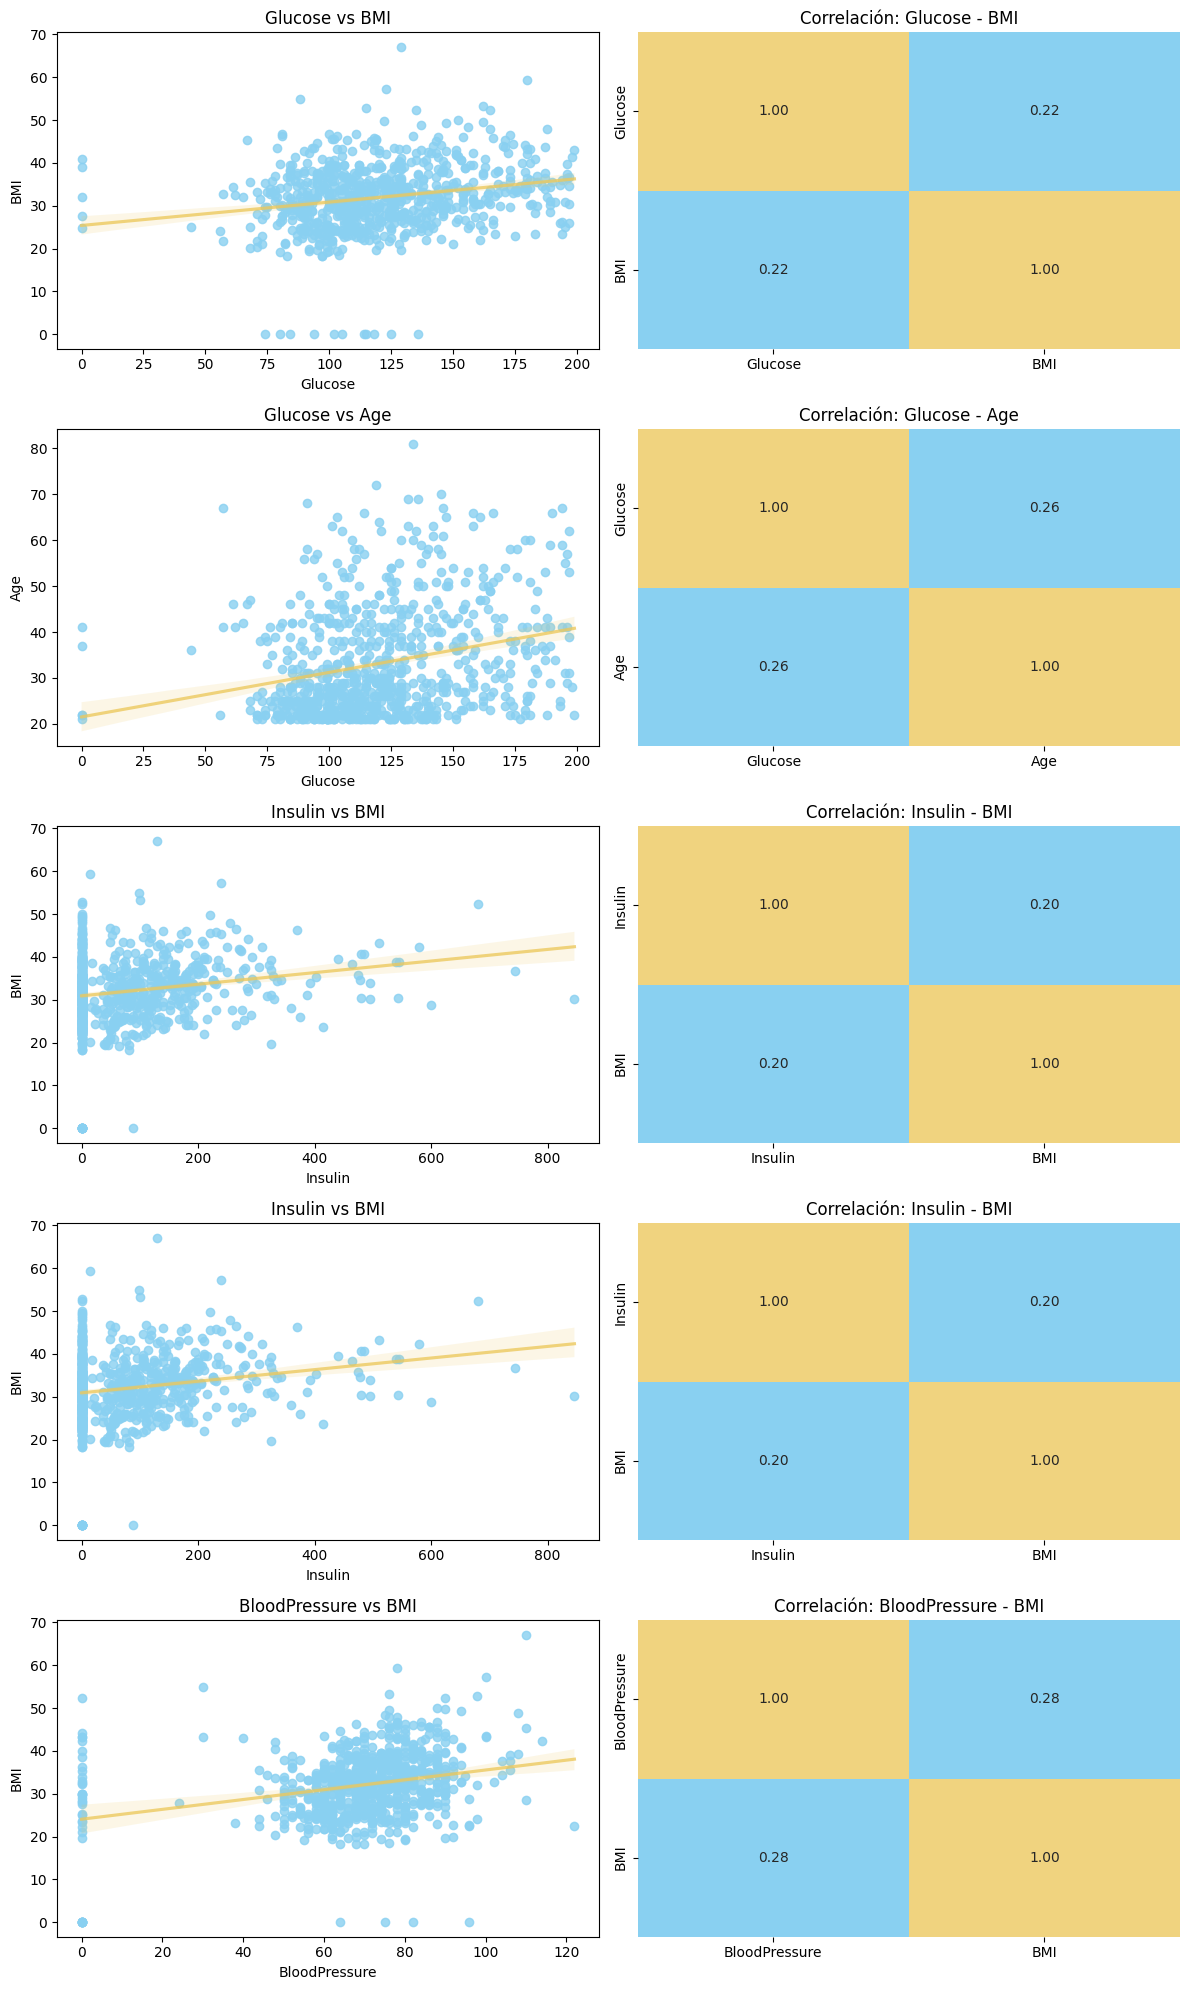

In [267]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

pairs = [
    ("Glucose", "BMI"),
    ("Glucose", "Age"),
    ("Insulin", "BMI"),
    ("Insulin", "BMI"),
    ("BloodPressure", "BMI")
]

# Crear paleta celeste → blanco → ámbar
cmap_custom = LinearSegmentedColormap.from_list(
    "celeste_ambar",
    ["#89D0F1", "white", "#ECC85CC8"]
)

fig, axes = plt.subplots(len(pairs), 2, figsize=(12, 4*len(pairs)))

for i, (x, y) in enumerate(pairs):

    # Regplot con colores personalizados
    sns.regplot(
        ax=axes[i, 0],
        data=total_data,
        x=x,
        y=y,
        scatter_kws={"color": "#89D0F1"},
        line_kws={"color": "#ECC85CC8"}
    )
    axes[i, 0].set_title(f"{x} vs {y}")

    # Heatmap con paleta personalizada
    corr = total_data[[x, y]].corr()
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap=cmap_custom,
        ax=axes[i, 1],
        cbar=False
    )
    axes[i, 1].set_title(f"Correlación: {x} - {y}")

plt.tight_layout()
plt.show()


INTERPRETACIÓN:
A mayor glucosa tiende a haber un IMC algo mayor, pero la relación más estrecha existe entre la Glucosa y la edad donde aumenta con tendencia ascendete conforme va teniendo más edad.

In [268]:
total_data["BMI_bin"] = pd.cut(
    total_data["BMI"],
    bins=[0, 18.5, 25, 30, 35, 40, 60],
    labels=["Bajo", "Normal", "Sobrepeso", "Obesidad I", "Obesidad II", "Obesidad III"]
)
total_data["Glucose_bin"] = pd.cut(
    total_data["Glucose"],
    bins=[0, 80, 100, 125, 150, 200, 300],
    labels=["<80", "80-100", "100-125", "125-150", "150-200", ">200"]
)

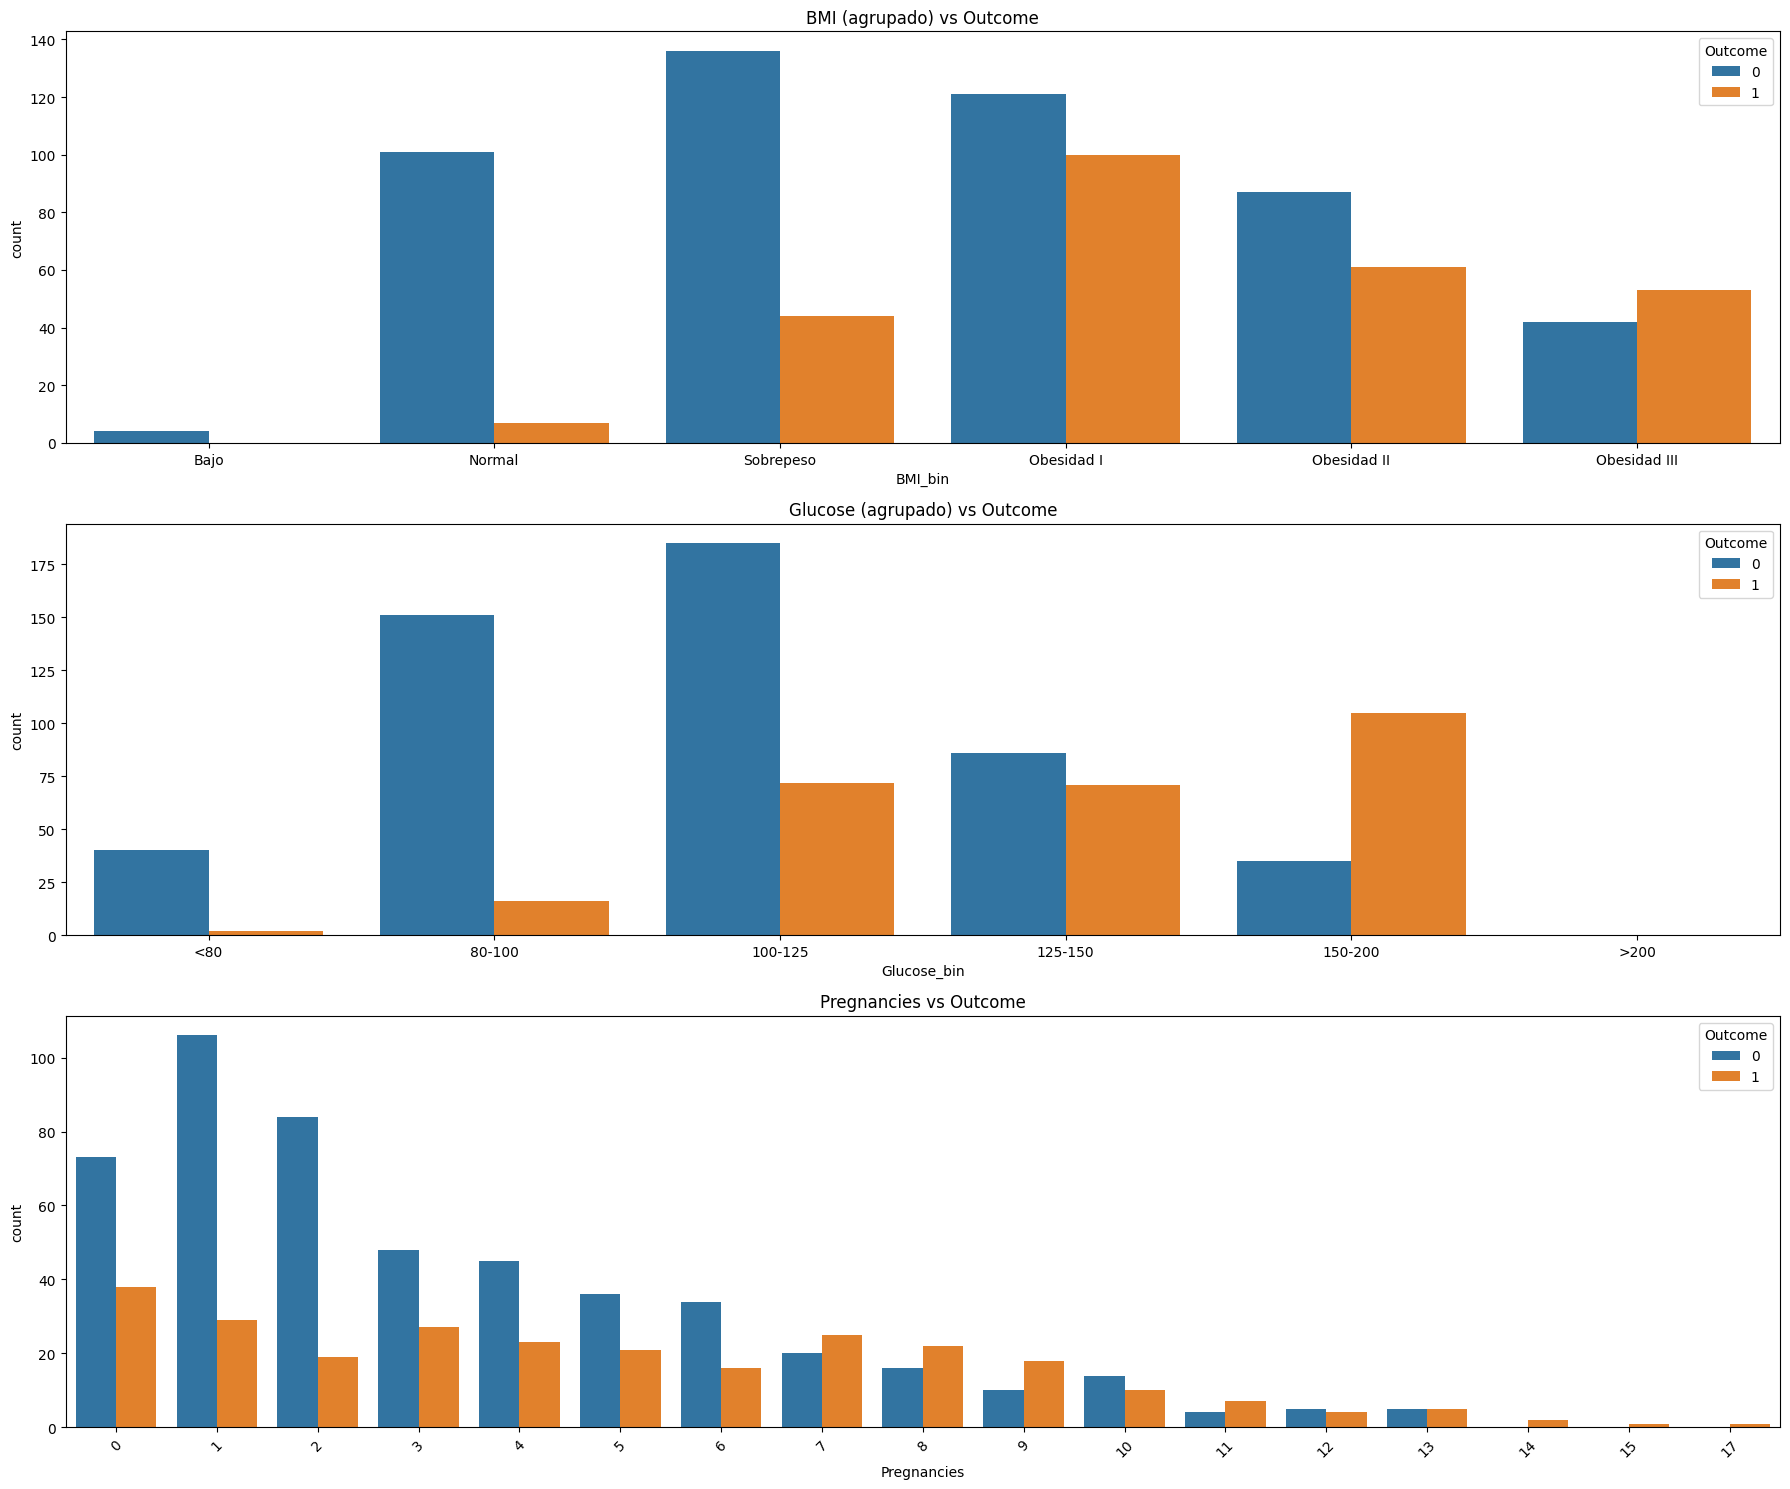

In [269]:
fig, axes = plt.subplots(3, 1, figsize=(18, 15))

# Gráfico 1: BMI agrupado
sns.countplot(
    ax=axes[0],
    data=total_data,
    x="BMI_bin",
    hue="Outcome"
)
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_title("BMI (agrupado) vs Outcome")

# Gráfico 2: Glucose agrupado
sns.countplot(
    ax=axes[1],
    data=total_data,
    x="Glucose_bin",
    hue="Outcome"
)
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_title("Glucose (agrupado) vs Outcome")

# Gráfico 3: Pregnancies (sin cambios)
sns.countplot(
    ax=axes[2],
    data=total_data,
    x="Pregnancies",
    hue="Outcome"
)
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_title("Pregnancies vs Outcome")

plt.tight_layout()
plt.show()


En el Primer Gráfico de Barras - IMC: El exceso de peso se asocia con mayor riesgo metabólico de resultar con Diabetes
En el Segundo Gráfico de Barras - Glucose: Niveles altos de glucosa están estrechamente ligados al diagnóstico de diabetes, lo cual es coherente con los criterios clínicos habituales.
En el Tercer Gráfico de Barras - Pregnacies: Algunos estudios se observa que más embarazos pueden asociarse a mayor riesgo de diabetes tipo 2, en parte por la relación con diabetes gestacional previa.

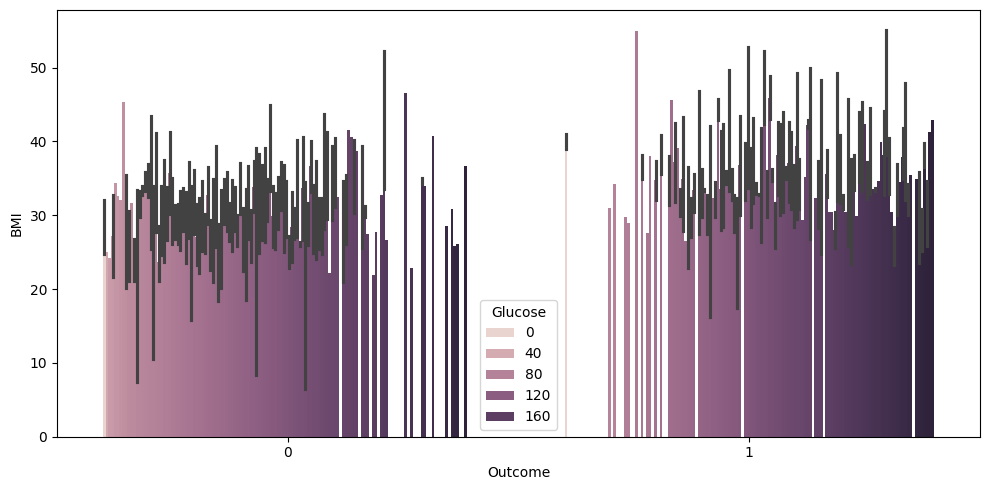

In [270]:
fig, axis = plt.subplots(figsize=(10, 5))

sns.barplot(ax=axis, data=total_data, x="Outcome", y="BMI", hue="Glucose")

plt.tight_layout()
plt.show()

Conclusión:
Las personas sin diabetes tienden a tener BMI moderado y glucosa baja. Asimismo, las personas con diabetes tienden a tener tanto más peso como más glucosa. 

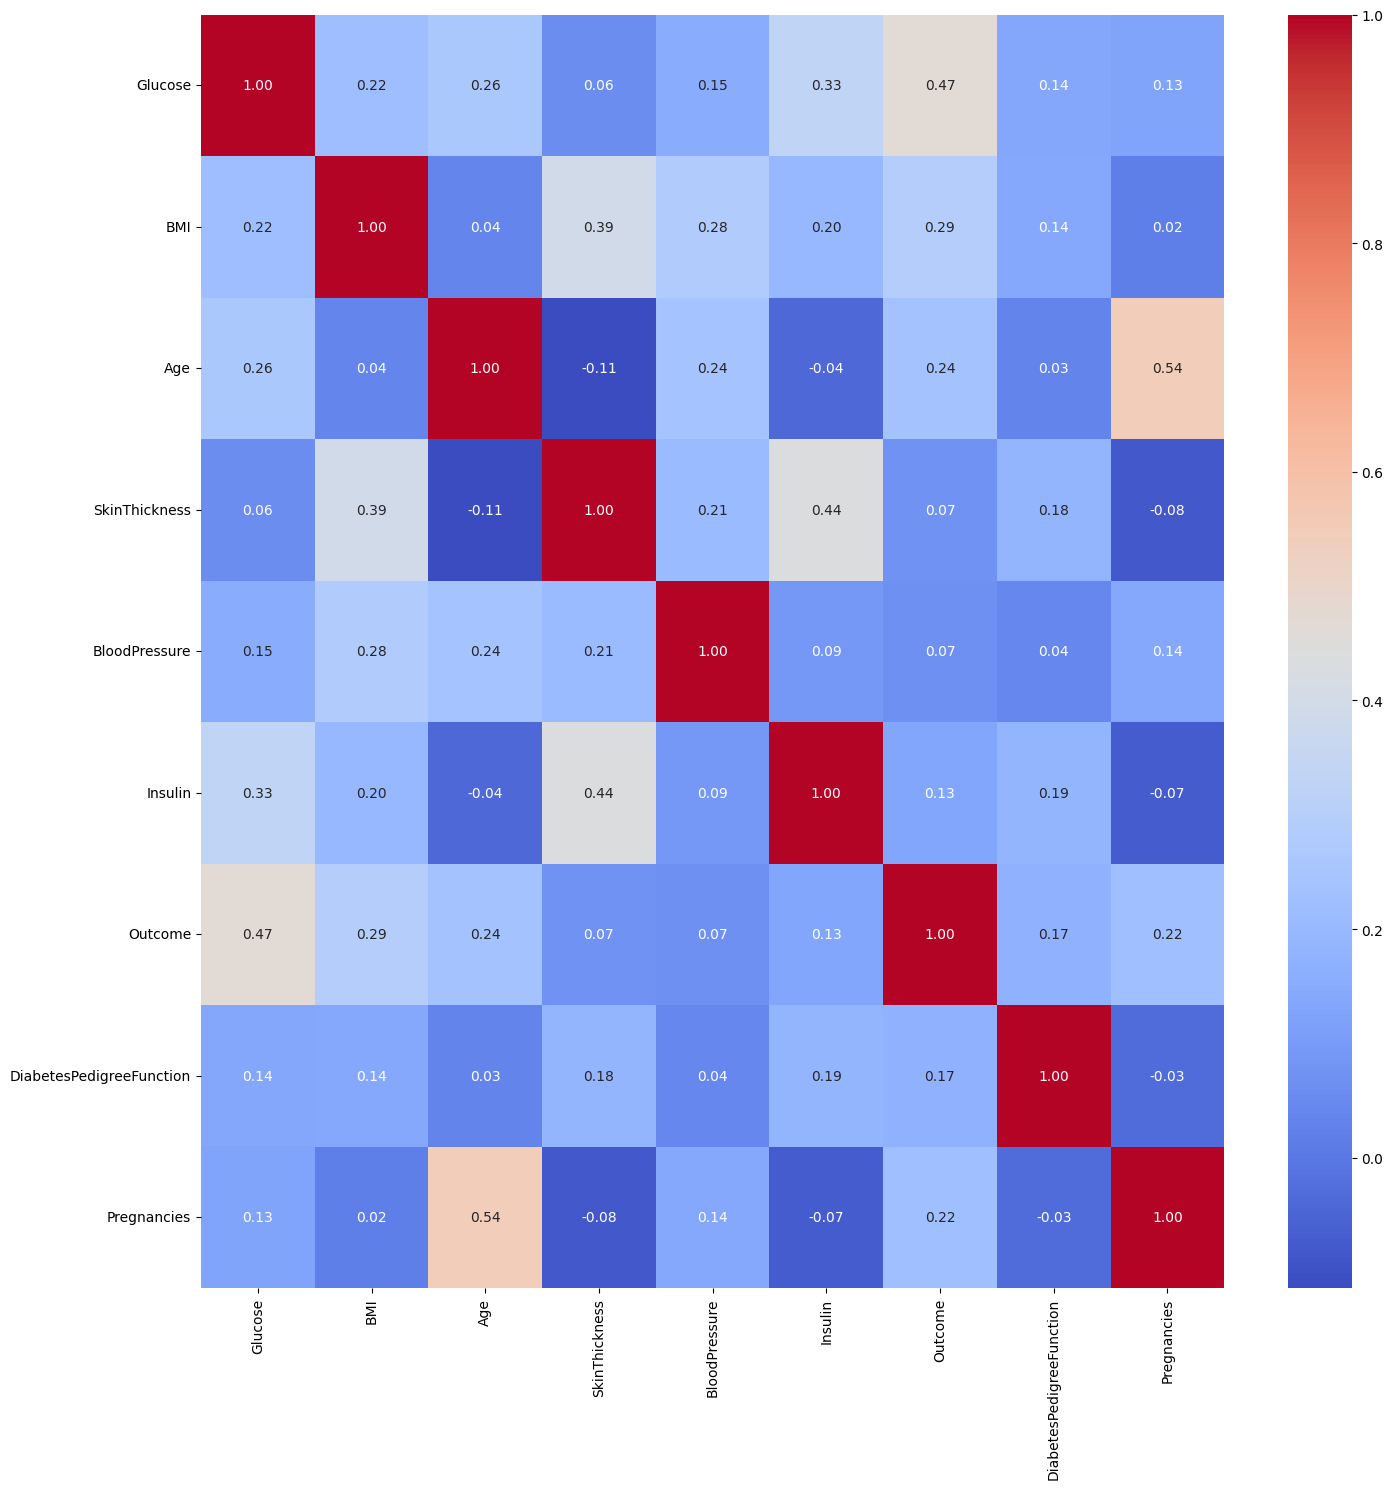

In [271]:
df_corr = total_data.copy()

# Dibujar el plot
plt.figure(figsize=(15, 15))
sns.heatmap(
    df_corr[["Glucose", "BMI", "Age", "SkinThickness", "BloodPressure",
             "Insulin", "Outcome", "DiabetesPedigreeFunction", "Pregnancies"]].corr(),
    annot=True, fmt=".2f", cmap="coolwarm"
)
plt.tight_layout()
plt.show()

Las variables que más se relacionan con el Outcome, con más riesgo de Diabetes son:

Glucose (la más fuerte con diferencia).

BMI (relación moderada).

Age y Pregnancies (relación moderada-baja).

El resto aporta información, pero con correlaciones bajas.

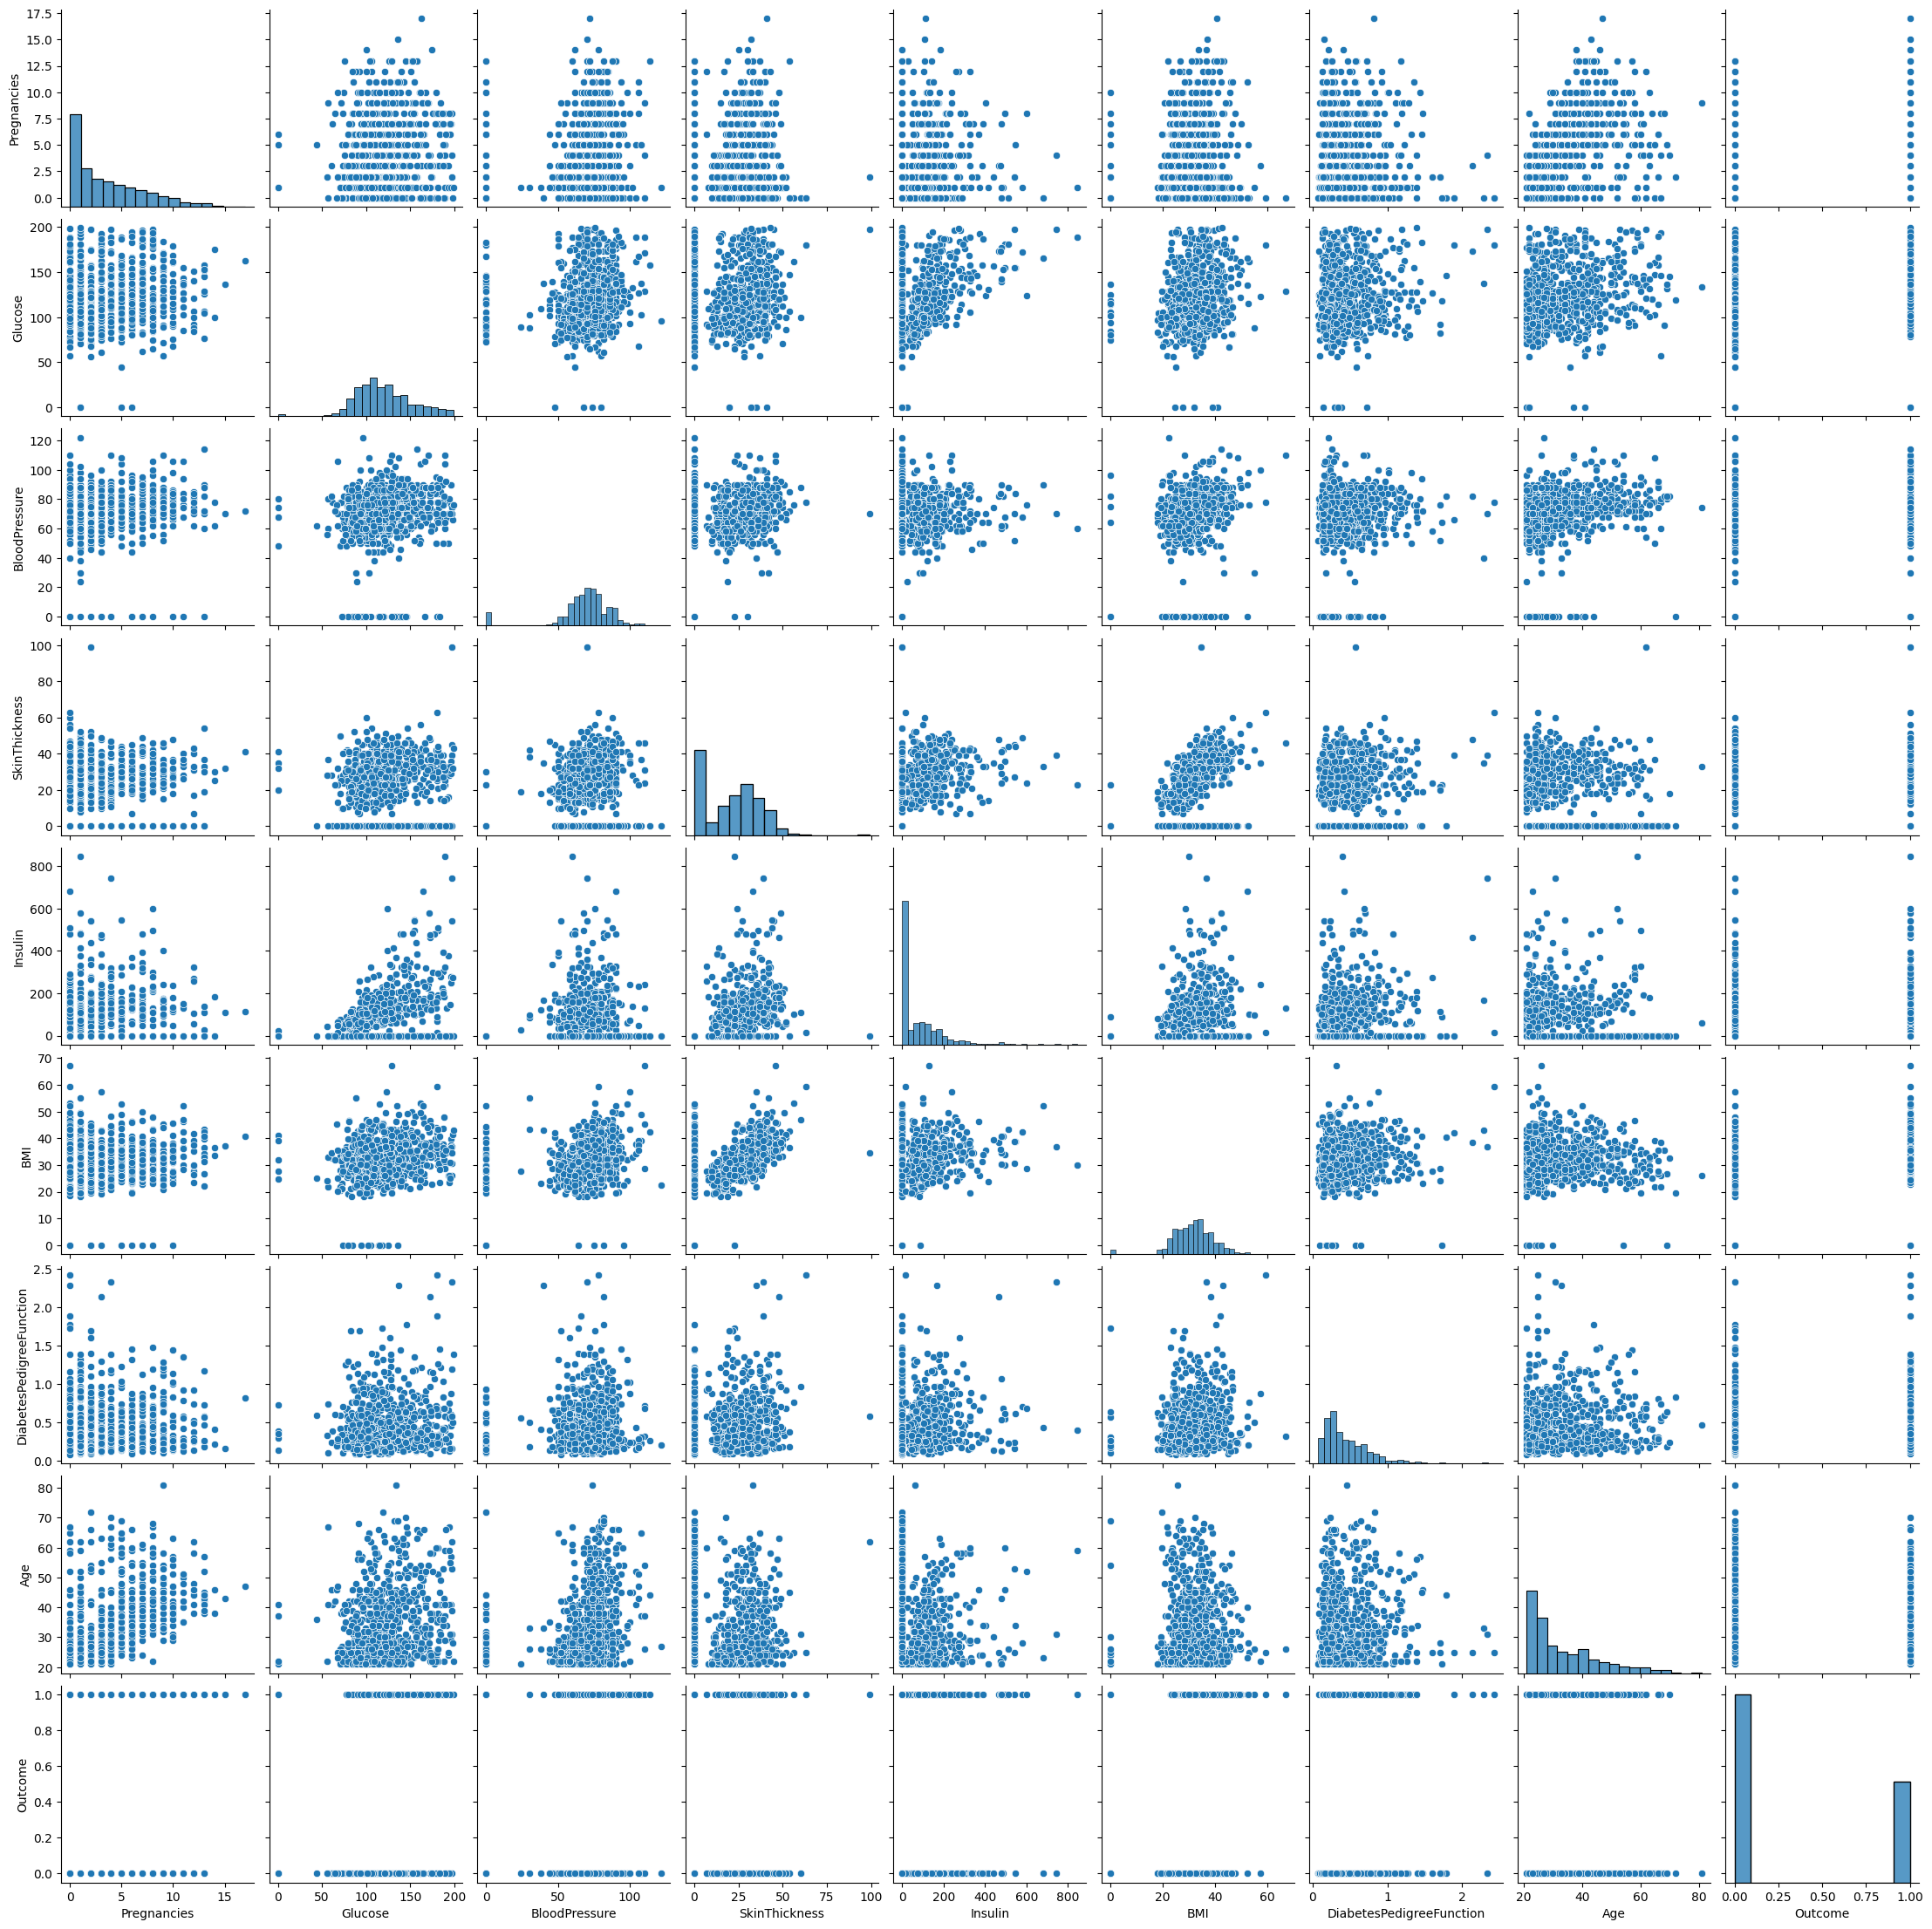

In [272]:
##ANÁLISIS DE TODA LA DATA EN UNA SOLA##
sns.pairplot(data = total_data)

Step 5: Ingeniería de Datos

In [273]:
total_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [274]:
import numpy as np

cols = ['Glucose', 'BloodPressure', 'Insulin', 'BMI', 'SkinThickness']

for col in cols:
    total_data[col] = total_data[col].replace(0, np.nan)


In [275]:
total_data = total_data.dropna(subset=cols)

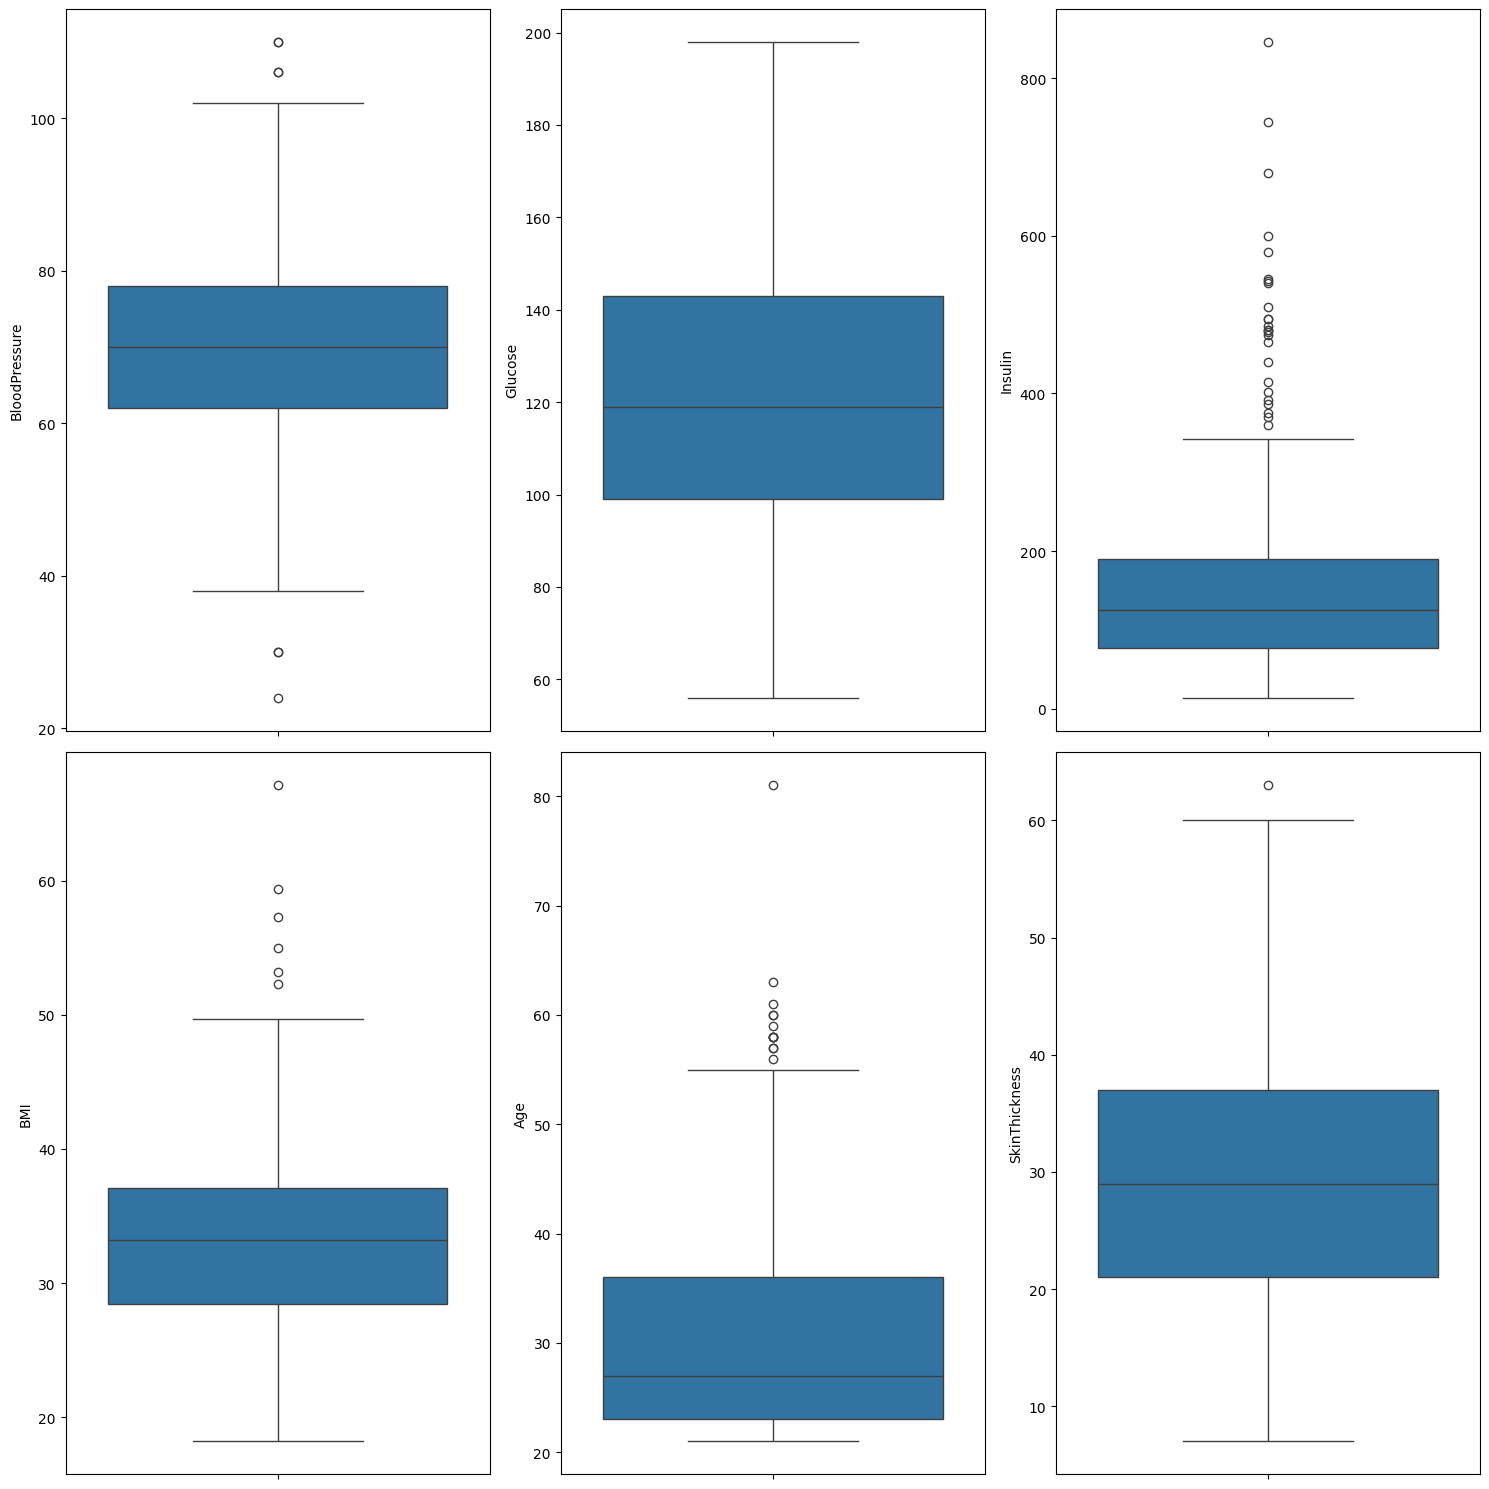

In [276]:
fig, axes = plt.subplots(2, 3, figsize = (15, 15))

sns.boxplot(ax = axes[0, 0], data = total_data, y = "BloodPressure")
sns.boxplot(ax = axes[0, 1], data = total_data, y = "Glucose")
sns.boxplot(ax = axes[0, 2], data = total_data, y = "Insulin")
sns.boxplot(ax = axes[1, 0], data = total_data, y = "BMI")
sns.boxplot(ax = axes[1, 1], data = total_data, y = "Age")
sns.boxplot(ax = axes[1, 2], data = total_data, y = "SkinThickness")

plt.tight_layout()

plt.show()

Variables limpias: 'BMI' y 'Age', de las cuales se pueden trabajar sin necesidad e eliminar outliers

Variables con outliers moderados: variable 'Pregnancies'.

Variables con problemas de calidad (valores 0): 'Glucose', 'Insulin', 'SkinThickness'.

Variables con dispersión extrema: 'Insulin'.

In [277]:
# Stats for 'Pregnancies'
pregnancies_stats = total_data["Pregnancies"].describe()
pregnancies_stats

count    392.000000
mean       3.301020
std        3.211424
min        0.000000
25%        1.000000
50%        2.000000
75%        5.000000
max       17.000000
Name: Pregnancies, dtype: float64

In [278]:
##Para la limpieza de outliers de BMI##
import numpy as np
total_data["log_BMI"] = np.log(total_data["BMI"])

In [279]:
# IQR para 'Pregnancies'

pregnancies_iqr = pregnancies_stats["75%"] - pregnancies_stats["25%"]
upper_limit = pregnancies_stats["75%"] + 1.5 * pregnancies_iqr
lower_limit = pregnancies_stats["25%"] - 1.5 * pregnancies_iqr

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(pregnancies_iqr, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 11.0 y -5.0, con un rango intercuartílico de 4.0


Hemos visto que para la variable 'Pregnancies', 'Glucose', 'Insulin' y 'SkinThickness' se requiere una limpieza de outliers

In [280]:
##Para la limpieza de outliers de la cola derecha, valores muy altos##
import numpy as np
max_allowed = 10  # por ejemplo
total_data['Pregnancies_capped'] = total_data['Pregnancies'].apply(lambda x: min(x, max_allowed))

Con este tipo de limpieza intento hacer lo siguiente: Sustituye todos los valores mayores que 10 por 10, ya sea que sea un valor >= que 10.

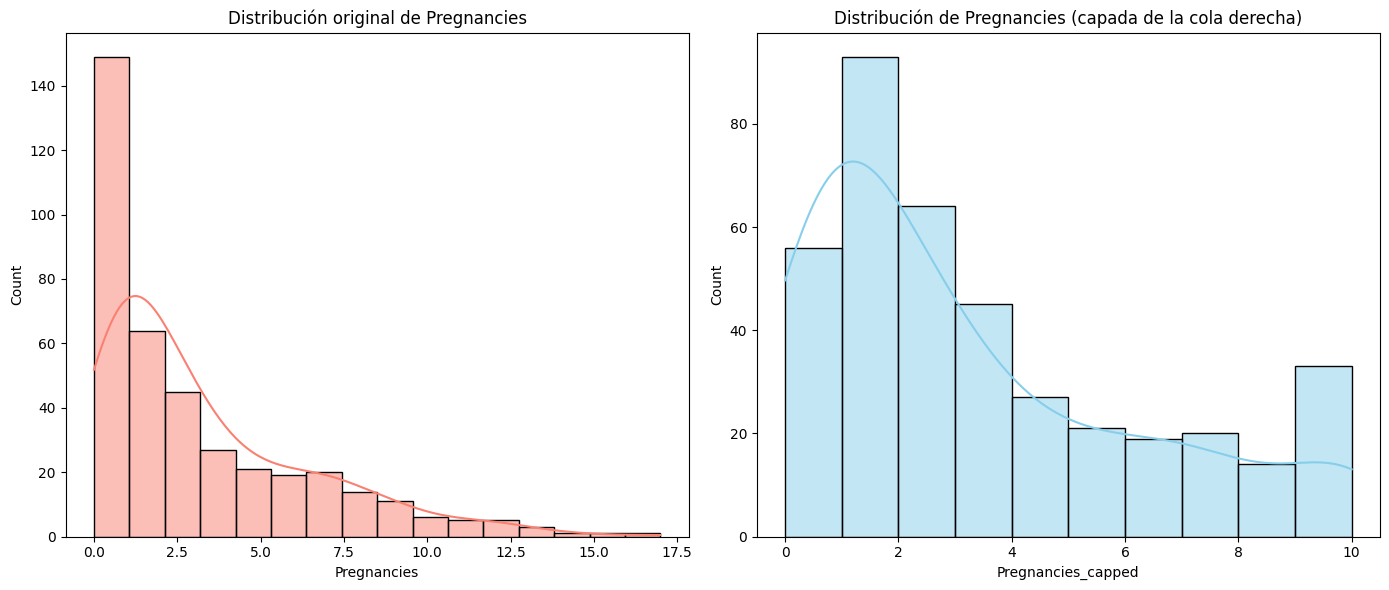

In [281]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Crear la variable capada (sin log)
max_allowed = 10
total_data["Pregnancies_capped"] = total_data["Pregnancies"].apply(lambda x: min(x, max_allowed))

# Graficar comparaciones
plt.figure(figsize=(14, 6))

# Distribución original
plt.subplot(1, 2, 1)
sns.histplot(total_data["Pregnancies"], kde=True, color="salmon")
plt.title("Distribución original de Pregnancies")
plt.xlabel("Pregnancies")

# Distribución capada
plt.subplot(1, 2, 2)
sns.histplot(total_data["Pregnancies_capped"], kde=True, color="skyblue")
plt.title("Distribución de Pregnancies (capada de la cola derecha)")
plt.xlabel("Pregnancies_capped")

plt.tight_layout()
plt.show()


In [282]:
from numpy._core.defchararray import upper
# TENEMOS QUE GUARDARNOS TODOS LOS DATASETS, ES DECIR:

total_data_CON_outliers = total_data.copy()
total_data_SIN_outliers = total_data.copy() # Lo vamos a modificar. Para cada variable con outliers, reemplazamos sus valores outliers

outliers_cols = ["Age", "BMI", "Glucose", "Insulin","BloodPressure", "Outcome"]

def replace_outliers(column, df):
  col_stats = total_data[column].describe()
  col_iqr = col_stats["75%"] - col_stats["25%"]
  upper_limit = round(float(col_stats["75%"] + 1.5 * col_iqr), 2)
  lower_limit = round(float(col_stats["25%"] - 1.5 * col_iqr), 2)

  if lower_limit < 0: lower_limit = min(df[column])
  # Vamos a quitar los outliers superiores
  df[column] = df[column].apply(lambda x: x if (x <= upper_limit) else upper_limit)
  # Vamos a quitar los outliers inferiores
  df[column] = df[column].apply(lambda x: x if (x >= lower_limit) else lower_limit)
  return df.copy(), [lower_limit, upper_limit]

outliers_dict = {}
for column in outliers_cols:
  total_data_SIN_outliers, limits = replace_outliers(column, total_data_SIN_outliers)
  outliers_dict.update({column: limits})

outliers_dict # Este JSON me lo tengo que GUARDAR

{'Age': [3.5, 55.5],
 'BMI': [15.35, 50.15],
 'Glucose': [33.0, 209.0],
 'Insulin': [14.0, 359.88],
 'BloodPressure': [38.0, 102.0],
 'Outcome': [0, 2.5]}

In [283]:
with open("./outliers_dict.json", "w") as f:
  json.dump(outliers_dict, f)

In [284]:
total_data_CON_outliers.isnull().sum().sort_values(ascending=False)

BMI_bin                     1
Glucose                     0
BloodPressure               0
SkinThickness               0
Pregnancies                 0
Insulin                     0
BMI                         0
Age                         0
DiabetesPedigreeFunction    0
Outcome                     0
Glucose_bin                 0
log_BMI                     0
Pregnancies_capped          0
dtype: int64

In [285]:
total_data_SIN_outliers.isnull().sum().sort_values(ascending=False)

BMI_bin                     1
Glucose                     0
BloodPressure               0
SkinThickness               0
Pregnancies                 0
Insulin                     0
BMI                         0
Age                         0
DiabetesPedigreeFunction    0
Outcome                     0
Glucose_bin                 0
log_BMI                     0
Pregnancies_capped          0
dtype: int64

In [286]:
total_data_CON_outliers = total_data.copy()

cols = ["BMI", "Glucose"]
for col in cols:
    total_data_CON_outliers[col] = total_data_CON_outliers[col].fillna(total_data_CON_outliers[col].median())

# Recalcular variables derivadas
total_data_CON_outliers["BMI_bin"] = pd.cut(
    total_data_CON_outliers["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Bajo", "Normal", "Sobrepeso", "Obesidad"]
)

In [287]:
total_data_CON_outliers.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
BMI_bin                     0
Glucose_bin                 0
log_BMI                     0
Pregnancies_capped          0
dtype: int64

In [288]:
total_data_CON_outliers["BMI"] = total_data["BMI"]
total_data_SIN_outliers["BMI"] = total_data_SIN_outliers["BMI"]

In [289]:
total_data_CON_outliers["Glucose"] = total_data["Glucose"]
total_data_SIN_outliers["Glucose"] = total_data_SIN_outliers["Glucose"]

In [290]:
total_data_CON_outliers["Probabilidad"] = (
    total_data_CON_outliers["Glucose"] + total_data_CON_outliers["BMI"]
)

total_data_SIN_outliers["Probabilidad"] = (
    total_data_SIN_outliers["Glucose"] + total_data_SIN_outliers["BMI"]
)


In [291]:
import sklearn
from sklearn.model_selection import train_test_split

# total_data_SIN_outliers
# total_data_CON_outliers

predictoras = ["Age", "BMI", "Glucose", "Insulin", "BloodPressure"]
target = ["Outcome"]

X_CON = total_data_CON_outliers.drop(target, axis = 1)[predictoras]
X_SIN = total_data_SIN_outliers.drop(target, axis = 1)[predictoras]
y = total_data_CON_outliers[target]

X_train_CON_outliers, X_test_CON_outliers, y_train, y_test = train_test_split(X_CON, y, test_size = 0.2, random_state = 10)
X_train_SIN_outliers, X_test_SIN_outliers = train_test_split(X_SIN, test_size = 0.2, random_state = 10)


In [292]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# X_train_CON_outliers
# X_train_SIN_outliers

# X_test_CON_outliers
# X_test_SIN_outliers

# TENGO QUE GUARDARME TRES SITUACIONES: 1) DATASET SIN TOCAR, 2) DATASET NORMALIZADO, 3) DATASET MIN-MAX

## NORMALIZACIÓN
### CON OUTLIERS
norm_CON_outliers = StandardScaler()
norm_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_norm = norm_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_norm = pd.DataFrame(X_train_CON_outliers_norm, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_norm = norm_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_norm = pd.DataFrame(X_test_CON_outliers_norm, index = X_test_CON_outliers.index, columns = predictoras)

### SIN OUTLIERS
norm_SIN_outliers = StandardScaler()
norm_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_norm = norm_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_norm = pd.DataFrame(X_train_SIN_outliers_norm, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_norm = norm_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_norm = pd.DataFrame(X_test_SIN_outliers_norm, index = X_test_SIN_outliers.index, columns = predictoras)


## ESCALADO MIN-MAX (MINMAXIMIZACIÓN)
### CON OUTLIERS
scaler_CON_outliers = MinMaxScaler()
scaler_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_scal = scaler_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_scal = pd.DataFrame(X_train_CON_outliers_scal, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_scal = scaler_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_scal = pd.DataFrame(X_test_CON_outliers_scal, index = X_test_CON_outliers.index, columns = predictoras)

### SIN OUTLIERS
scaler_SIN_outliers = MinMaxScaler()
scaler_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_scal = scaler_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_scal = pd.DataFrame(X_train_SIN_outliers_scal, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_scal = scaler_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_scal = pd.DataFrame(X_test_SIN_outliers_scal, index = X_test_SIN_outliers.index, columns = predictoras)

# X_train_CON_outliers
# X_train_CON_outliers_norm
# X_train_CON_outliers_scal
# X_train_SIN_outliers
# X_train_SIN_outliers_norm
# X_train_SIN_outliers_scal

# X_test_CON_outliers
# X_test_CON_outliers_norm
# X_test_CON_outliers_scal
# X_test_SIN_outliers
# X_test_SIN_outliers_norm
# X_test_SIN_outliers_scal

In [293]:
X_train_CON_outliers.to_excel("../data/processed/X_train_CON_outliers.xlsx")
X_train_CON_outliers.to_excel("../data/processed/X_train_CON_outliers_norm.xlsx")
X_train_CON_outliers_scal.to_excel("../data/processed/X_train_CON_outliers_scal.xlsx")

X_train_SIN_outliers.to_excel("../data/processed/X_train_SIN_outliers.xlsx")
X_train_SIN_outliers_norm.to_excel("../data/processed/X_train_SIN_outliers_norm.xlsx")
X_train_SIN_outliers_scal.to_excel("../data/processed/X_train_SIN_outliers_scal.xlsx")

y_train.to_excel("../data/processed/y_train.xlsx")

In [294]:
import pandas as pd

X_train_CON_outliers = pd.read_excel("../data/processed/X_train_CON_outliers.xlsx")
X_train_CON_outliers_norm = pd.read_excel("../data/processed/X_train_CON_outliers_norm.xlsx")
X_train_CON_outliers_scal = pd.read_excel("../data/processed/X_train_CON_outliers_scal.xlsx")

X_train_SIN_outliers = pd.read_excel("../data/processed/X_train_SIN_outliers.xlsx")
X_train_SIN_outliers_norm = pd.read_excel("../data/processed/X_train_SIN_outliers_norm.xlsx")
X_train_SIN_outliers_scal = pd.read_excel("../data/processed/X_train_SIN_outliers_scal.xlsx")

y_train = pd.read_excel("../data/processed/y_train.xlsx")

In [295]:
# Data processing
# ==================================================================================
import pandas as pd
import numpy as np

# Charts
# ==================================================================================
import matplotlib.pyplot as plt

# Preprocessing and modeling
# ==================================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ParameterGrid
# from sklearn.inspection import permutation_importance
from sklearn import tree


Step 1: Tomando decisión: Cuál es el mejor dataset

In [296]:
X_train_CON_outliers = pd.read_excel("../data/processed/X_train_CON_outliers.xlsx")
X_train_SIN_outliers = pd.read_excel("../data/processed/X_train_SIN_outliers.xlsx")
y_train = pd.read_excel("../data/processed/y_train.xlsx")

In [297]:
y_train = y_train.values.ravel()

In [298]:
y_test = y_test.values.ravel()

In [299]:
train_dicts = {
  "X_train_CON_outliers": X_train_CON_outliers,
  "X_train_SIN_outliers": X_train_SIN_outliers
}

# test_dicts (dict)
# =====================================================================================
test_dicts = {
  "X_test_CON_outliers": X_test_CON_outliers,
  "X_test_SIN_outliers": X_test_SIN_outliers
}

# -.-.--.-.-.-.-.-.-.-.--.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.--.-.-.-.-.-.-

# train_dfs (list)
# =====================================================================================
train_dfs = [
  X_train_CON_outliers,
  X_train_SIN_outliers
]

# test_dfs (list)
# =====================================================================================
test_dfs = [
  X_test_CON_outliers,
  X_test_SIN_outliers
]

# -.-.--.-.-.-.-.-.-.-.--.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.-.--.-.-.-.-.-.-

# Print .shape
# =====================================================================================
print("|X_train|")
print("=================================================================")
print(f"X_train_CON_outliers shape: {X_train_CON_outliers.shape} ")
print(f"X_train_SIN_outliers shape: {X_train_SIN_outliers.shape}\n ")

print("|X_test|")
print("=================================================================")
print(f"X_test_CON_outliers shape: {X_test_CON_outliers.shape} ")
print(f"X_test_SIN_outliers shape: {X_test_SIN_outliers.shape}\n ")

print("|Y_train|")
print("=================================================================")
print(f"y_train shape: {y_train.shape}\n ")

print("|Y_test|")
print("=================================================================")
print(f"y_test shape: {y_test.shape} ")

|X_train|
X_train_CON_outliers shape: (313, 6) 
X_train_SIN_outliers shape: (313, 6)
 
|X_test|
X_test_CON_outliers shape: (79, 5) 
X_test_SIN_outliers shape: (79, 5)
 
|Y_train|
y_train shape: (626,)
 
|Y_test|
y_test shape: (79,) 


In [300]:
import pandas as pd

# Convertir y_train en Series con índice consecutivo
y_train = pd.Series(y_train)


El dataframe que se considera entrenar en principio tiene 313 filas y el eje "Y" tiene 626 filas

In [301]:
y_train_dfs = [
    y_train.iloc[:313],   # para X_train_CON_outliers
    y_train.iloc[313:]    # para X_train_SIN_outliers
]

In [302]:
print(train_dfs[0].shape, y_train_dfs[0].shape)
print(train_dfs[1].shape, y_train_dfs[1].shape)

(313, 6) (313,)
(313, 6) (313,)


Sin embargo, también existen valores '0' en 'Unnamed', entonces para que pueda ejecutar con éxito esta primera parte del Paso 1: Tomar el mejor Dataset.

In [303]:
for name, df in train_dicts.items():
    if "Unnamed: 0" in df.columns:
        train_dicts[name] = df.drop(columns=["Unnamed: 0"])

for name, df in test_dicts.items():
    if "Unnamed: 0" in df.columns:
        test_dicts[name] = df.drop(columns=["Unnamed: 0"])


 Se eliminan las columnas de Unnamed: 0

In [304]:
train_dfs = [df.drop(columns=["Unnamed: 0"]) if "Unnamed: 0" in df.columns else df for df in train_dfs]
test_dfs  = [df.drop(columns=["Unnamed: 0"]) if "Unnamed: 0" in df.columns else df for df in test_dfs]


In [305]:
results = []

for df_index in range(len(train_dfs)):
    model = DecisionTreeClassifier(random_state=42)

    train_df = train_dfs[df_index]
    y_sub = y_train_dfs[df_index]

    model.fit(train_df, y_sub)

    y_test_pred = model.predict(test_dfs[df_index])

    results.append({
        "index": df_index,
        "train_df": list(train_dicts.keys())[df_index],
        "Accuracy_score": accuracy_score(y_test, y_test_pred)
    })

resultados = sorted(results, key=lambda x: x["Accuracy_score"], reverse=True)
resultados


[{'index': 1,
  'train_df': 'X_train_SIN_outliers',
  'Accuracy_score': 0.2911392405063291},
 {'index': 0,
  'train_df': 'X_train_CON_outliers',
  'Accuracy_score': 0.27848101265822783}]

In [306]:
print (f"The best train dataframe is |{resultados[0]['train_df']}|.\n\
=======================================================      \n\
| Accuracy score: {resultados[0]['Accuracy_score']}   |\n\
========================================")

The best train dataframe is |X_train_SIN_outliers|.
| Accuracy score: 0.2911392405063291   |


Step 2: Optimización de hiperparámetros

 2.1 Grid SearchCV

In [307]:
model = DecisionTreeClassifier(random_state = 42)
model.fit(train_df, y_sub)
y_pred = model.predict(test_dfs[0])

base_accuracy = accuracy_score(y_test, y_pred)
print(f" The base_accuracy is: {base_accuracy}")

 The base_accuracy is: 0.2911392405063291


In [308]:
grid = GridSearchCV(model, hyperparams, scoring="accuracy", cv=8)

model_grid = grid.fit(train_df, y_sub)

In [309]:
best_tree = model_grid.best_estimator_

In [310]:
type(model_grid)


sklearn.model_selection._search.GridSearchCV

In [311]:
best_tree = model_grid.best_estimator_
# We define the parameters that we want to adjust by hand
hyperparams = {
    "criterion": ["entropy", "gini"], # 'gini' es generalmente más rápido, mientras que, 'entropy' puede ser preferible si se busca una medida basada en la información
    "max_depth": [8, 10, 12, 14, 16], # Significa que el árbol no tendrá más de 12 niveles. Valor mayor = complejo / Valor menor = simplificado.
    "random_state": [42], # To obtain a deterministic behaviour during fitting, random_state has to be fixed to an integer.
    "splitter": ["best", "random"], # The strategy used to choose the split at each node
        # 'best' (elige la mejor división) tiende a dar un rendimiento más alto 
        # & 
        # 'random' (elige una división aleatoria) puede ser más rápido y útil para modelos como Random Forest.
    "min_weight_fraction_leaf": [0.085, 0.09, 0.095, 0.1, 0.15, 0.2]
}

# We initialize the grid
grid = GridSearchCV(model, hyperparams, scoring = "accuracy", cv = 8)
grid

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['entropy', 'gini'], 'max_depth': [8, 10, ...], 'min_weight_fraction_leaf': [0.085, 0.09, ...], 'random_state': [42], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",8
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for ea

In [312]:
grid.fit(train_df, y_sub)

print(f"Best hyperparameters: {grid.best_params_}")

Best hyperparameters: {'criterion': 'entropy', 'max_depth': 8, 'min_weight_fraction_leaf': 0.2, 'random_state': 42, 'splitter': 'random'}


In [313]:
model_grid = DecisionTreeClassifier(criterion = 'gini',
                                    max_depth = 8,
                                    min_weight_fraction_leaf = 0.09,
                                    random_state = 42,
                                    splitter = 'best')
model_grid.fit(train_df, y_sub)

y_pred = model_grid.predict(test_dfs[1])

grid_accuracy = accuracy_score(y_test, y_pred)
print(f" The grid_accuracy is: {grid_accuracy}")

 The grid_accuracy is: 0.6455696202531646


In [314]:
print(f"We have an increment of {round(((grid_accuracy - base_accuracy)/base_accuracy)*100, 2)}%")

We have an increment of 121.74%


In [315]:
from sklearn.tree import export_text

decision_tree = export_text(model_grid, feature_names = train_dfs[0].columns)
print(decision_tree)

|--- BMI <= 29.95
|   |--- Age <= 26.50
|   |   |--- Insulin <= 85.50
|   |   |   |--- class: 0
|   |   |--- Insulin >  85.50
|   |   |   |--- class: 0
|   |--- Age >  26.50
|   |   |--- class: 0
|--- BMI >  29.95
|   |--- BMI <= 33.25
|   |   |--- class: 1
|   |--- BMI >  33.25
|   |   |--- Glucose <= 149.50
|   |   |   |--- Glucose <= 110.00
|   |   |   |   |--- class: 0
|   |   |   |--- Glucose >  110.00
|   |   |   |   |--- BMI <= 37.25
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- BMI >  37.25
|   |   |   |   |   |--- class: 0
|   |   |--- Glucose >  149.50
|   |   |   |--- class: 0



In [316]:
import pandas as pd

# Asegurar que y_train es 1D
y_train = pd.Series(y_train).astype(int)


In [317]:
np.unique(y_train)


array([  0,   1,   3,   6,   8,  13,  14,  18,  19,  20,  24,  25,  28,
        31,  32,  35,  39,  40,  43,  50,  51,  52,  53,  56,  63,  68,
        69,  70,  71,  73,  82,  85,  87,  88,  91,  92,  94,  95,  97,
        99, 103, 105, 108, 109, 110, 111, 114, 119, 120, 125, 126, 127,
       128, 132, 134, 139, 142, 144, 147, 150, 152, 153, 156, 157, 158,
       159, 162, 165, 169, 171, 173, 174, 175, 177, 181, 187, 188, 189,
       191, 195, 197, 198, 199, 215, 216, 220, 223, 224, 225, 229, 231,
       236, 241, 243, 244, 248, 252, 254, 258, 259, 260, 271, 273, 275,
       281, 282, 285, 286, 287, 288, 290, 291, 292, 293, 295, 296, 297,
       298, 301, 302, 305, 306, 307, 309, 311, 312, 313, 316, 318, 320,
       323, 325, 328, 329, 331, 335, 338, 340, 341, 346, 353, 356, 358,
       359, 360, 364, 368, 369, 370, 372, 373, 374, 377, 380, 382, 383,
       384, 385, 388, 389, 390, 392, 393, 395, 396, 402, 409, 412, 413,
       414, 420, 422, 424, 425, 427, 428, 429, 431, 432, 441, 44

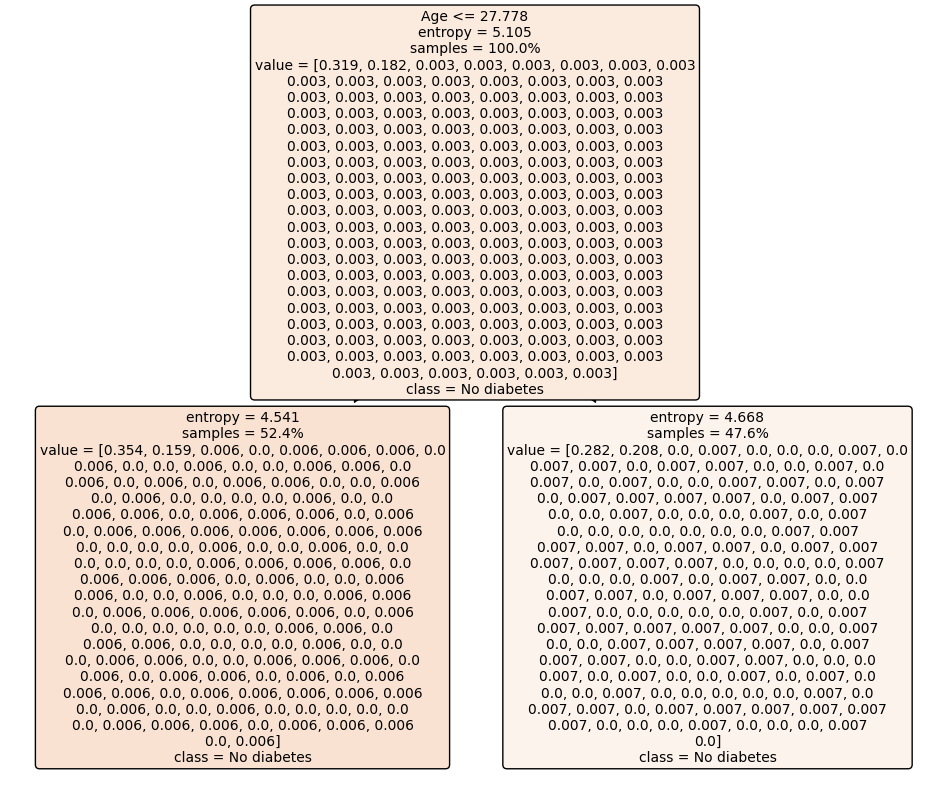

In [318]:
plt.figure(figsize=(12,10))

plot_tree(
    best_tree,
    feature_names=train_dfs[0].columns,
    class_names=["No diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=10
)

plt.show()


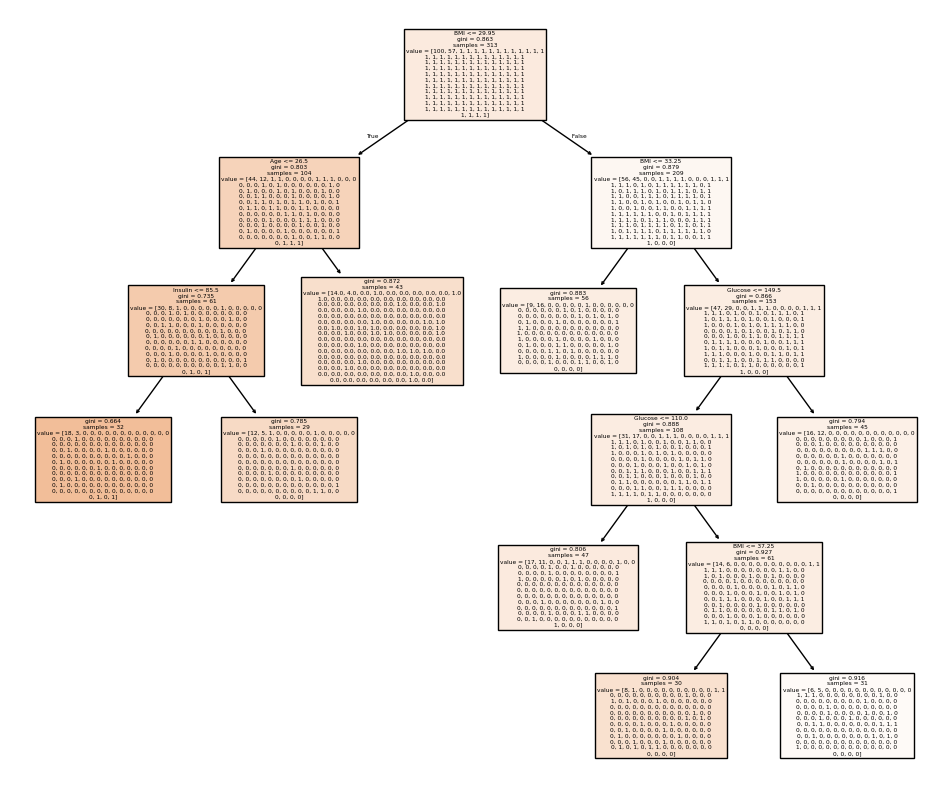

In [319]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,10))

plot_tree(model_grid, 
            feature_names = train_df.columns, 
                filled = True
)

plt.show()